In [1]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [2]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()

In [16]:
holding_period = 65
tickers = sp500["ticker"].values
positions = 10
training_year = datetime.now().year - 2
today = datetime(2023,12,12)
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
week = today.isocalendar()[1] if today.weekday() != 0 else today.isocalendar()[1] - 1
week_mod = int(week % (holding_period/5))
print(week_mod,week,)

11 50


In [4]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices.copy()
        simulation.sort_values("date",inplace=True)
        simulation["return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period*2)) / simulation["adjclose"].shift(holding_period*2)
        simulation["risk"] = simulation["adjclose"].rolling(holding_period*2).std() / simulation["adjclose"].rolling(holding_period*2).mean()
        simulation["abs"] = simulation["return"] / simulation["risk"]
        simulation["buy_price"] = simulation["adjclose"].shift(-1)
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"] + timedelta(days=int(holding_period /5) * 7)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"]
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|█▎        | 65/503 [00:10<00:55,  7.85it/s]

'date'


model_prep:  16%|█▌        | 79/503 [00:13<01:21,  5.18it/s]

'date'


model_prep: 100%|██████████| 503/503 [01:22<00:00,  6.08it/s]

'date'
'date'
'date'


In [5]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")

In [17]:
## backtest
trades = sim[sim["weekday"]==weekday].copy()
trades = trades[trades["week"] % int(holding_period/5) == week_mod]
trades = trades.sort_values("abs",ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()

In [18]:
trades = processor.column_date_processing(trades[["date","sell_date","buy_price","sell_price","abs","ticker","GICS Sector","adjclose","return"]])

In [19]:
trades.sort_values("date").tail(30)

,date,sell_date,buy_price,sell_price,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
274,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,115.280857,114.931469,4.281576,DHI,Consumer Discretionary,115.559650,-0.003031,2023,2,6,24,0
189,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,410.149904,455.770849,4.882519,NVDA,Information Technology,394.752536,0.111230,2023,2,6,24,0
193,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,478.990000,552.160000,4.864455,ADBE,Information Technology,474.630000,0.152759,2023,2,6,24,0
327,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,141.181853,144.261172,3.884124,AMAT,Information Technology,139.409487,0.021811,2023,2,6,24,0
320,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,115.271865,117.315007,3.978865,LEN,Consumer Discretionary,114.665746,0.017725,2023,2,6,24,0
210,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,115.852477,113.246841,4.727045,ORCL,Information Technology,115.604250,-0.022491,2023,2,6,24,0
214,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,271.320000,311.720000,4.699413,META,Communication Services,271.050000,0.148902,2023,2,6,24,0
231,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,220.380000,209.050000,4.643118,BA,Industrials,221.560000,-0.051411,2023,2,6,24,0
240,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,73.575175,78.415499,4.557453,PHM,Consumer Discretionary,72.589394,0.065787,2023,2,6,24,0
67,2023-06-12 00:00:00+00:00,2023-09-11 00:00:00+00:00,841.863605,866.839128,5.474888,AVGO,Information Technology,846.057493,0.029667,2023,2,6,24,0


In [20]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
portfolio["return"] = portfolio["return"] * (1/positions) + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [21]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

In [22]:
portfolio

,date,return,year,cr,quarter,month,week,weekday,realtime_start,realtime_end,value,bcr
0,2021-03-15 00:00:00+00:00,0.949793,2021,0.949793,1,3,11,0,2023-12-10,2023-12-10,3968.94,1.000000
1,2021-06-14 00:00:00+00:00,1.073018,2021,1.019144,2,6,24,0,2023-12-10,2023-12-10,4255.15,1.072112
2,2021-09-13 00:00:00+00:00,1.046573,2021,1.066609,3,9,37,0,2023-12-10,2023-12-10,4468.73,1.125925
3,2021-12-13 00:00:00+00:00,0.931183,2021,0.993208,4,12,50,0,2023-12-10,2023-12-10,4668.97,1.176377
4,2022-03-14 00:00:00+00:00,1.101791,2022,1.094308,1,3,11,0,2023-12-10,2023-12-10,4173.11,1.051442
5,2022-06-13 00:00:00+00:00,0.955567,2022,1.045684,2,6,24,0,2023-12-10,2023-12-10,3749.63,0.944743
6,2022-09-12 00:00:00+00:00,1.038340,2022,1.085775,3,9,37,0,2023-12-10,2023-12-10,4110.41,1.035644
7,2022-12-12 00:00:00+00:00,0.971557,2022,1.054892,4,12,50,0,2023-12-10,2023-12-10,3990.56,1.005447
8,2023-03-13 00:00:00+00:00,1.065261,2023,1.123735,1,3,11,0,2023-12-10,2023-12-10,3855.76,0.971484
9,2023-06-12 00:00:00+00:00,1.047095,2023,1.176657,2,6,24,0,2023-12-10,2023-12-10,4338.93,1.093221


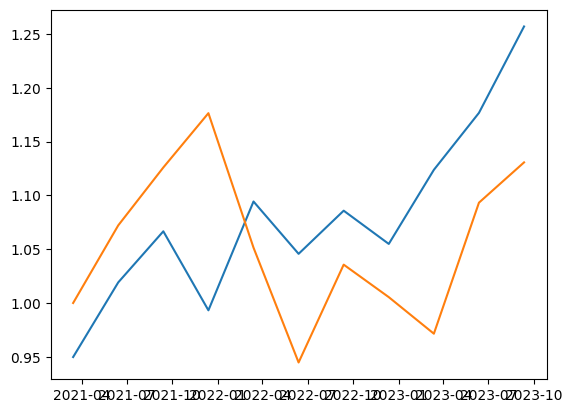

In [23]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [24]:
recommendations = trades.sort_values(["date","abs"]).tail(positions)

In [25]:
recommendations

,date,sell_date,buy_price,sell_price,abs,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
109,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,629.50,NaN,5.273892,COST,Consumer Staples,623.86,NaN,2023,4,12,50,0
85,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,88.20,NaN,5.384652,NTAP,Information Technology,89.75,NaN,2023,4,12,50,0
72,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,273.01,NaN,5.432259,FDX,Industrials,271.38,NaN,2023,4,12,50,0
56,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,160.44,NaN,5.583891,TMUS,Communication Services,158.85,NaN,2023,4,12,50,0
52,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,633.66,NaN,5.625625,ADBE,Information Technology,625.20,NaN,2023,4,12,50,0
50,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,95.46,NaN,5.652564,APH,Information Technology,95.24,NaN,2023,4,12,50,0
26,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,503.65,NaN,6.057194,LULU,Consumer Discretionary,502.74,NaN,2023,4,12,50,0
25,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,1072.28,NaN,6.089231,AVGO,Information Technology,1029.24,NaN,2023,4,12,50,0
24,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,509.58,NaN,6.114402,URI,Industrials,505.14,NaN,2023,4,12,50,0
10,2023-12-11 00:00:00+00:00,2024-03-11 00:00:00+00:00,97.63,NaN,6.548732,PCAR,Industrials,97.93,NaN,2023,4,12,50,0


In [26]:
db.connect()
db.drop('portfolio')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()